In [1]:
# import modules
from mssf import ConvergenceCallback
from mssf import stepSelectionVI
import numpy as np
import random
import math
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import os
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors 

np.set_printoptions(suppress=True)

2024-02-21 11:35:03.272267: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-21 11:35:03.272325: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-21 11:35:03.272343: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-21 11:35:03.278795: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load data
beta=np.array([[0.1,0]])
nbObs=10001
pos_filename = "pos_N_" + str(nbObs-1) + "_b1_" + str(beta[0][0]) + "_b2_" + str(beta[0][1]) + ".csv"
grid_filename = "cov_N_" + str(nbObs-1) + "_b1_" + str(beta[0][0]) + "_b2_" + str(beta[0][1]) + ".npy"

# get home directory from os
home_dir = os.path.expanduser("~")
data_dir = os.path.join(home_dir, "mssf-vi","mssf-vi")

df = pd.read_csv(data_dir + "/data/" + pos_filename)

xy1 = df[["x", "y"]].values
dt = df["time"].values
ID = df["ID"].values
cov_cube = np.load(data_dir + "/data/" + grid_filename)

In [3]:
# preprocessing steps convert to tensors and handle the change of ID, start/end points and time between fixes
start_points = []
end_points = []
step_times = []
for i in np.unique(ID):
    cxy = xy1[ID==i]#[:1024*100+1]
    cdt = dt[ID==i]#[:1024*100+1]
    if cdt.shape[0]<2:
        continue
    start_points.append(cxy[:-1])
    end_points.append(cxy[1:])
    step_times.append(np.atleast_2d(cdt[:-1]).T)

    
indexes = np.arange(np.vstack(start_points).shape[0])
np.random.shuffle(indexes)
start_points = tf.convert_to_tensor(np.vstack(start_points)[indexes],dtype=tf.float32)
end_points = tf.convert_to_tensor(np.vstack(end_points)[indexes],dtype=tf.float32)
step_times = tf.convert_to_tensor(np.vstack(step_times)[indexes],dtype=tf.float32)
cov_tensor = tf.transpose(tf.convert_to_tensor(cov_cube,dtype=tf.float32),[2,1,0])

L = 50.0 # size of domain
x_ref_min = [0., 0.]
x_ref_max = [L, L]

2024-02-21 11:35:22.450625: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14793 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0001:00:00.0, compute capability: 7.5


In [5]:
# Create the instance of the model and set up the training
ssf = stepSelectionVI(2, cov_tensor, move_std=2.00, L=50.0, n_gh_points=3, n_gh_points_vi=5)

2024-02-21 11:36:00.793790: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


In [6]:
# set up the dataset and optimizer
batch_size = 1000
train_dataset = tf.data.Dataset.from_tensor_slices(
        (start_points, end_points, step_times))
train_dataset = train_dataset.batch(batch_size, drop_remainder=True)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.1, use_ema=True, ema_overwrite_frequency=10)
kl_weight = batch_size/start_points.shape[0]
ssf.compile(optimizer=optimizer, loss_weights=kl_weight)
convergence_callback = ConvergenceCallback(threshold=1e-3)

In [7]:
# Model fitting
max_epochs = 500
ssf.fit(train_dataset, epochs=max_epochs, callbacks=[convergence_callback])

Epoch 1/500


2024-02-21 11:36:23.881530: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f4e64064ec0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-02-21 11:36:23.881579: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2024-02-21 11:36:23.886147: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2024-02-21 11:36:23.901019: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2024-02-21 11:36:23.986396: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 [==============================] - 8s 238ms/step - loss: 2949.0444
Epoch 2/500
10/10 [==============================] - 2s 233ms/step - loss: 2941.6836
Epoch 3/500
10/10 [==============================] - 2s 238ms/step - loss: 2933.4119
Epoch 4/500
10/10 [==============================] - 2s 237ms/step - loss: 2925.8291
Epoch 5/500
10/10 [==============================] - 2s 232ms/step - loss: 2918.8301
Epoch 6/500
10/10 [==============================] - 2s 234ms/step - loss: 2912.3501
Epoch 7/500
10/10 [==============================] - 2s 238ms/step - loss: 2906.3589
Epoch 8/500
10/10 [==============================] - 2s 239ms/step - loss: 2900.8269
Epoch 9/500
10/10 [==============================] - 2s 234ms/step - loss: 2895.7334
Epoch 10/500
10/10 [==============================] - 2s 234ms/step - loss: 2891.0571
Epoch 11/500
10/10 [==============================] - 2s 239ms/step - loss: 2886.7749
Epoch 12/500
10/10 [==============================] - 2s 235ms/step - loss:

In [20]:
############################ Utilisation distribution  ##########################################

# Parameters from the posterior distributions 
b1mean = ssf.beta_mean.numpy()[0] # Mean for cov 1
b1scale = ssf.beta_std.numpy()[0,0] # Standard deviation for cov 1
b2mean = ssf.beta_mean.numpy()[1] # Mean for cov 2
b2scale = ssf.beta_std.numpy()[0,1] # Standard deviation for cov 2


################## Credible interval #############################################################
# For Covariates 1
Lci1=b1mean-1.96*b1scale
Uci1=b1mean + 1.96*b1scale

################## Utilization distribution #########################################################
cov1=cov_cube[0]
# Lower credible interval
UDL=np.exp(Lci1*cov1)
UDL=np.divide(UDL,np.sum(UDL))

UDU=np.exp(Uci1*cov1)
UDU=np.divide(UDU,np.sum(UDU))

# Mean utilisation distribution
UDM=np.exp(b1mean*cov1)
UDM=np.divide(UDM,np.sum(UDM))

In [21]:
# Sampling 100 betas from the posterior distribution
S = 100
d1=ssf.variational_posterior.sample(S).numpy()

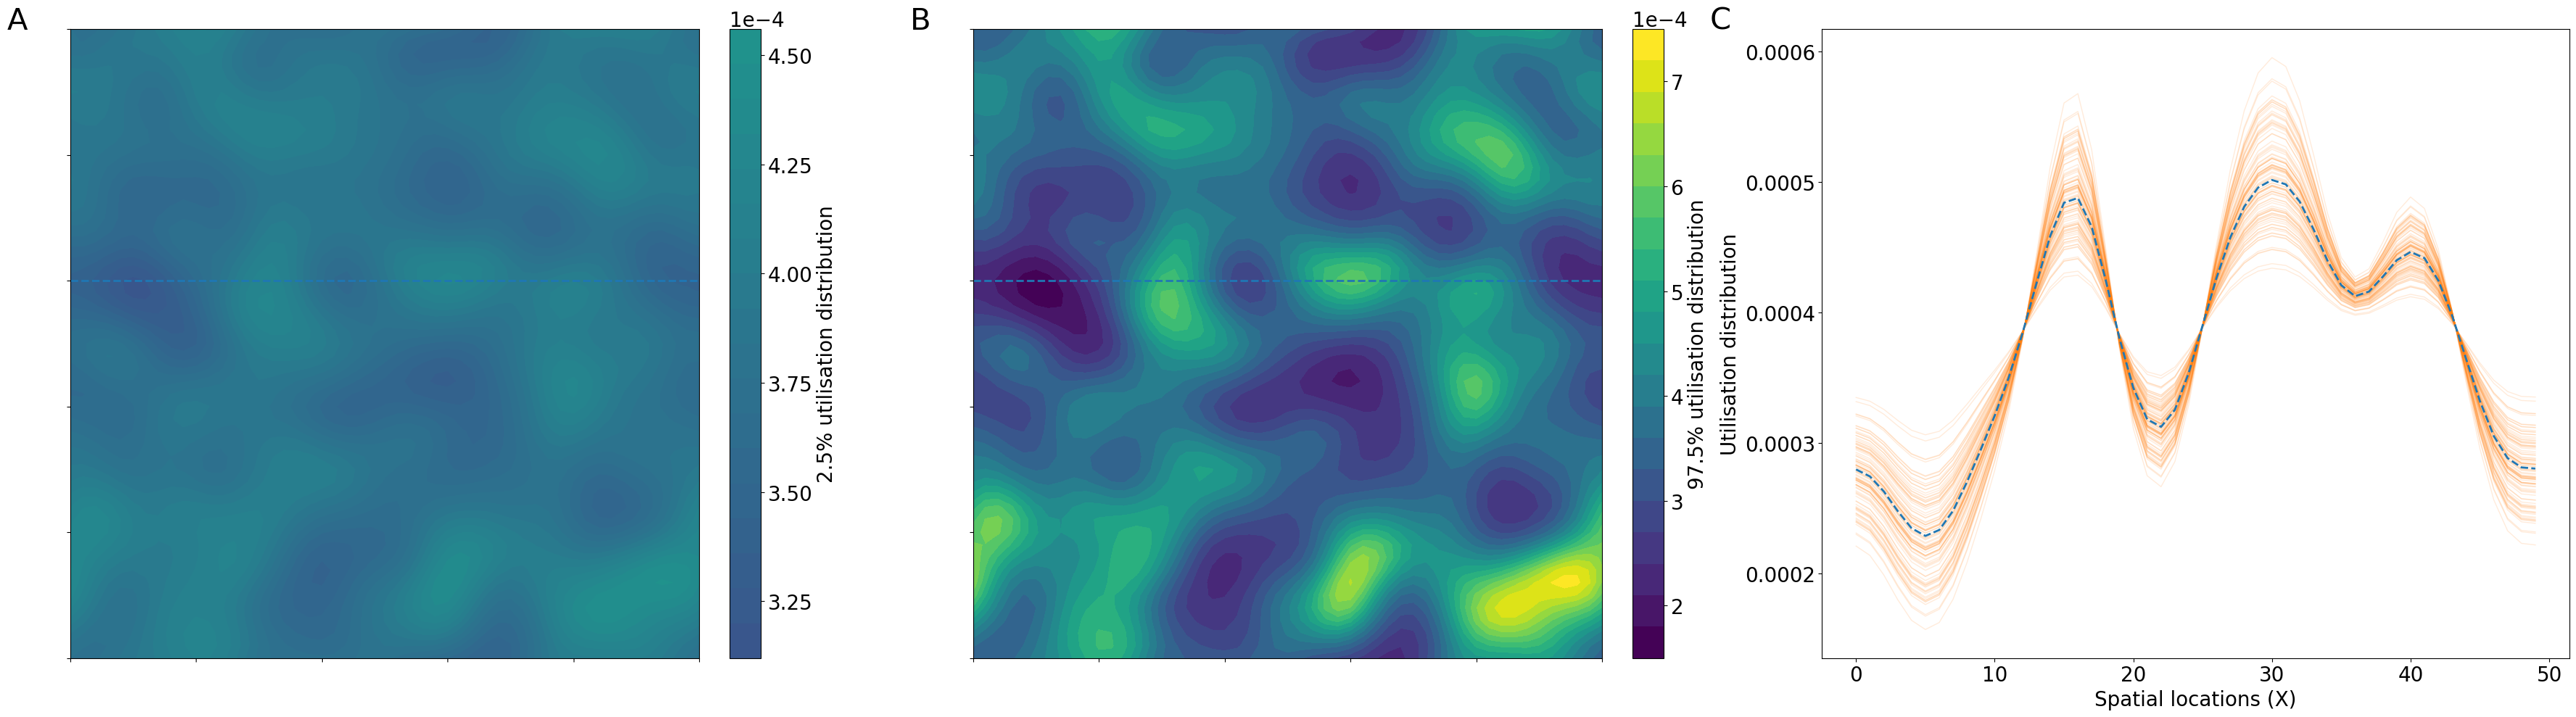

In [26]:

## Plotting 2 by 2 for utilisation distribution, environment covariates 1 and
## line graph on the same panel

import matplotlib.ticker as tick #Importing tick function

fig, axs = plt.subplots(1, 3, figsize=(36,10),tight_layout=True)

# Figure A
# Setting aspect ratio 
axs[0].set_aspect('equal')
ax0= axs[0].contourf(UDL,cmap='viridis',levels=20,vmin=UDU.min(),vmax=UDU.max())#,vmin=UDU.min(),vmax=UDU.max())
axs[0].text(-0.1,1,'A', size=30, transform=axs[0].transAxes)
axs[0].tick_params( labelleft=False, labelbottom=False) 
axs[0].axhline(30,color="C0",ls="--",linewidth=2)
cbar = fig.colorbar(ax0, ax=axs[0],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left') 
cbar.set_label(label=r'2.5% utilisation distribution',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

# Figure B
axs[1].set_aspect('equal')
ax11 = axs[1].contourf(UDU,cmap='viridis',levels=20,vmin=UDU.min(),vmax=UDU.max())#vmin=UDU.min(),vmax=UDU.max())
axs[1].text(-0.1,1,'B', size=30, transform=axs[1].transAxes)
axs[1].axhline(30,color="C0",ls="--",linewidth=2)
axs[1].tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax11, ax=axs[1],fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.ax.tick_params(labelsize=20) 
cbar.set_label(label=r'97.5% utilisation distribution',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

# Figure C
b1=d1[:,0,0] # Beta 1
for i in range(S):
    UDS1=np.exp(b1[i]*cov1)
    UDS1=np.divide(UDS1,np.sum(UDS1))
    axs[2].plot(UDS1[30,0:50], color="C1",linewidth=1.0,alpha=0.15)
axs[2].plot(UDM[30,0:50],color="C0", linewidth=2,ls="--")
axs[2].set_xlabel("Spatial locations (X)",fontsize=20)
axs[2].set_ylabel("Utilisation distribution",fontsize=20)
axs[2].tick_params(axis='both', which='major', labelsize=20)
axs[2].text(-0.15,1,'C', size=30, transform=axs[2].transAxes)

fig.subplots_adjust(wspace=0.1, hspace=0.1)

plt.tight_layout()
plt.savefig("Figure_4.png",bbox_inches='tight',dpi=300)
plt.savefig("Figure_4.pdf",bbox_inches='tight',dpi=300)
plt.show()

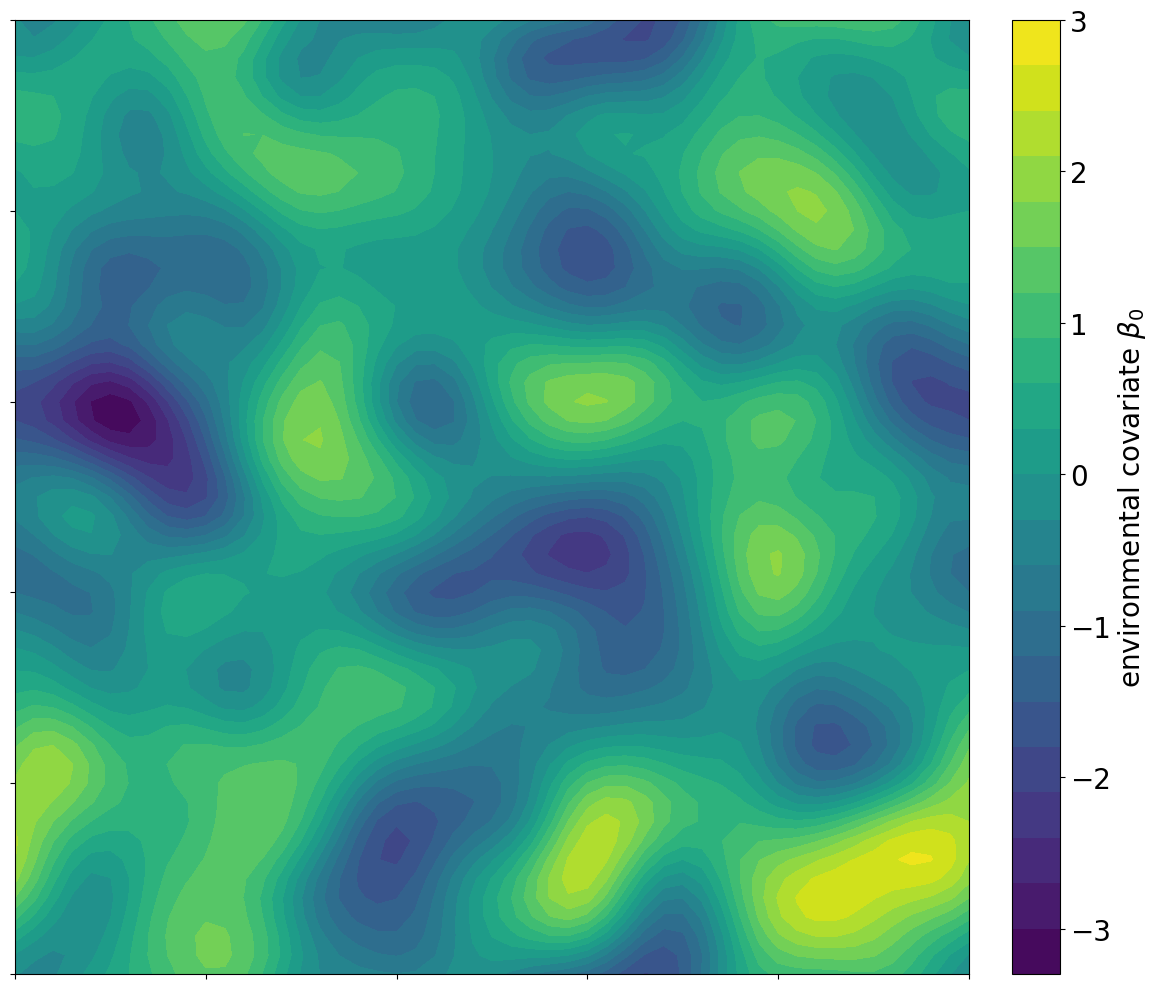

In [27]:
# Supplementary materials for environmental covariate
# figure B
#Axes.set_aspect('equal')
#fig,axs=plt.subplot()
#axs.set_aspect("equal")
# Figure A
# Setting aspect ratio 
fig, axs = plt.subplots(1, 1, figsize=(12,10),tight_layout=True)
axs.set_aspect('equal')
ax1=axs.contourf(cov1,cmap='viridis',levels=20)
#axs[0,0].set_title('A',loc='left',size=30,pad=100)
#axs.text(-0.15,1,'B', size=30, transform=axs.transAxes)
axs.tick_params( labelleft=False, labelbottom=False) 
cbar = fig.colorbar(ax1, ax=axs,fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=20) 
cbar.formatter.set_powerlimits((0, 0))
cbar.ax.yaxis.get_offset_text().set_fontsize(20)
cbar.ax.yaxis.set_offset_position('left')                         
cbar.set_label(label=r'environmental covariate $\beta_0$',size=20)
tick_locator = tick.MaxNLocator(nbins=7)
cbar.locator = tick_locator
cbar.update_ticks()

plt.savefig("Figure_2S.png",bbox_inches='tight',dpi=300)
plt.savefig("Figure_2s.pdf",bbox_inches='tight',dpi=300)
plt.show()

/tmp/ipykernel_236/3224492481.py:18: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar=plt.colorbar()


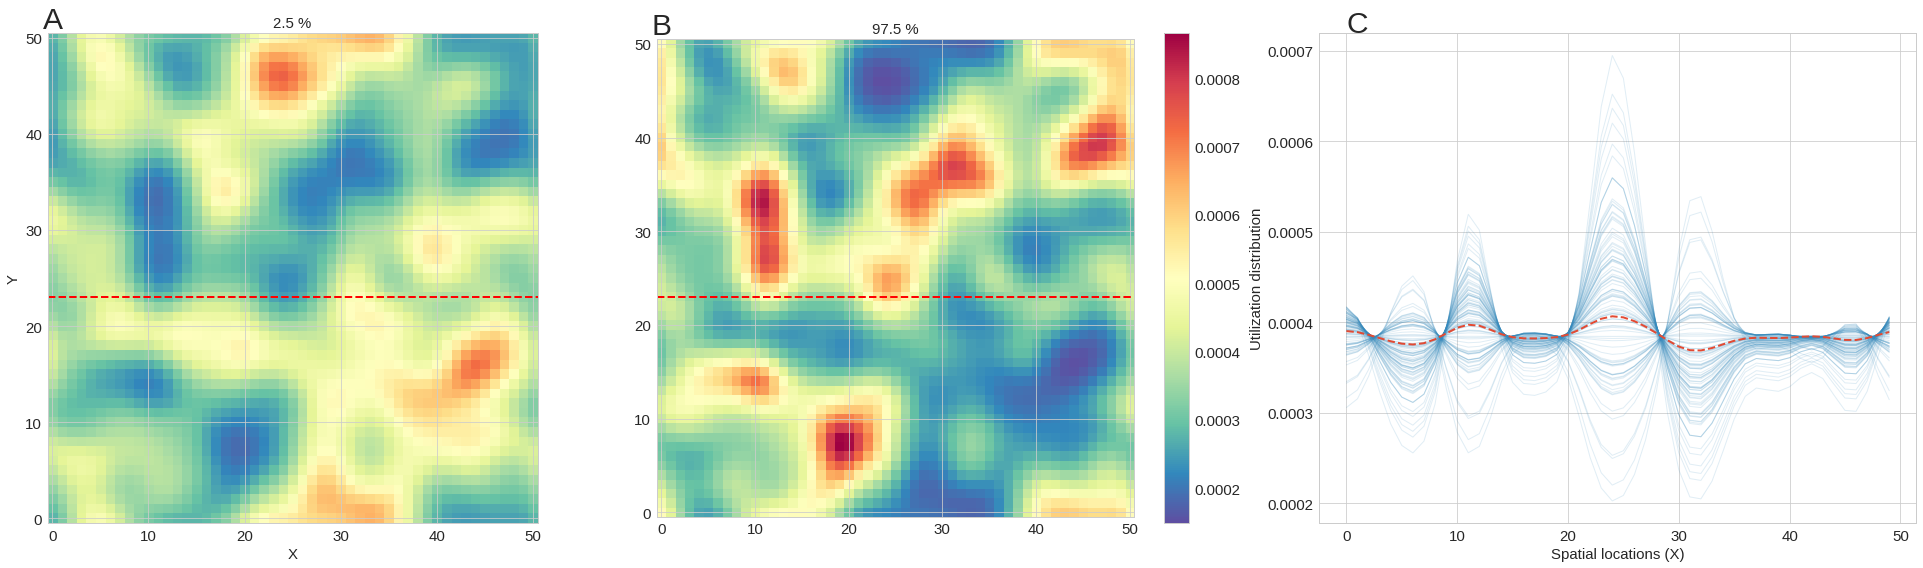

In [51]:
fig = plt.figure(figsize=(27, 8))

fig.add_subplot(1, 3, 1)
plt.imshow(UDL,origin="lower",vmin=UDU.min(),vmax=UDU.max(),cmap='Spectral_r')
plt.axhline(23,color="red",ls="--",linewidth=2)
plt.text(-1,51,'A', fontsize=30)
plt.title('2.5 %',fontsize=15)
plt.xlabel("X",fontsize=15)
plt.ylabel("Y",fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)

fig.add_subplot(1, 3, 2)
plt.imshow(UDU,origin="lower",vmin=UDU.min(),vmax=UDU.max(),cmap='Spectral_r')
plt.axhline(23,color="red",ls="--",linewidth=2)
plt.text(-1,51,'B', fontsize=30)
plt.title('97.5 %',fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
cbar=plt.colorbar()
cbar.ax.tick_params(labelsize=15) 
cbar.update_ticks()
plt.tight_layout()

# Plotting log-likelihood of beta sampled randomly from the posterior distribution
ax = fig.add_subplot(1, 3, 3)
b1=d1[:,0,0] # Beta 1
b2=d1[:,0,1] #Beta 2
for i in range(S):
    UDS1=np.exp(b1[i]*cov1)
    UDS1=np.divide(UDS1,np.sum(UDS1))
    plt.plot(UDS1[23,0:50], color="C1",linewidth=1.0,alpha=0.15)
plt.plot(UDM[23,0:50],color="C0", linewidth=2,ls="--")
plt.xlabel("Spatial locations (X)",fontsize=15)
plt.ylabel("Utilization distribution",fontsize=15)
plt.text(0,0.00072,'C', fontsize=30)
plt.tick_params(axis='both', which='major', labelsize=15)


# Retain only unique labels
#handles, labels = plt.gca().get_legend_handles_labels()
#by_label = dict(zip(labels, handles))
#plt.legend(by_label.values(), by_label.keys(),loc="best",fontsize=14)

plt.tight_layout()

#plt.savefig('./Figures_4.png',dpi=300)
#plt.savefig('./Figures_4.pdf',dpi=300)

plt.show()

In [ ]:
# Setting plotting style
# plt.style.use('ggplot') 
# plt.style.use('seaborn-paper') 
# plt.style.use('seaborn-whitegrid')